# Netflix TV Show Success Prediction 🎬

## Problem Statement

Can we predict whether a Netflix TV show will be successful based on engagement metrics, genre, and release year?

## Dataset Description

- Dataset contains 16,000+ Netflix TV shows  
- Features include: vote_count, popularity, genre, release_year  
- Target variable: Success (vote_average ≥ 7)  
- Only TV Shows were considered for modeling  

## Methodology

1. Data cleaning and preprocessing  
2. Feature engineering (genre extraction and encoding)  
3. Exploratory Data Analysis (EDA)  
4. Logistic Regression model  
5. Random Forest model  
6. Model evaluation using Accuracy, Precision, Recall, and F1-score  

In [26]:
import pandas as pd

df = pd.read_csv("netflix_shows.csv")  # replace with exact CSV name
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average
0,33238,TV Show,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,1 Seasons,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241
1,32415,TV Show,Conan,NaN,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,1 Seasons,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035
2,37757,TV Show,MasterChef Greece,NaN,NaN,Greece,2010-10-03,2010,5.600,1 Seasons,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600
3,75685,TV Show,Prostřeno!,NaN,"Václav Vydra, Jana Boušková",Czech Republic,2010-03-01,2010,6.500,1 Seasons,Reality,cs,The knives (and forks) are out as a group of s...,1095.776,6,6.500
4,33847,TV Show,The Talk,NaN,"Amanda Kloots, Jerry O'Connell, Akbar Gbaja-Bi...","United States of America, Ireland",2010-10-18,2010,3.400,1 Seasons,Talk,en,A panel of well-known news and entertainment p...,712.070,12,3.400


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      5035 non-null   object 
 4   cast          14843 non-null  object 
 5   country       14203 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        15026 non-null  object 
 11  language      16000 non-null  object 
 12  description   12794 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
dtypes: float64(3), int64(3), object(10)
memory usage: 2.0+ MB


In [28]:
df['success'] = df['vote_average'].apply(lambda x: 1 if x >= 7 else 0)
df[['vote_average', 'success']].head()

,vote_average,success
0,8.241,1
1,7.035,1
2,5.600,0
3,6.500,0
4,3.400,0


In [29]:
df['success'].value_counts()

success
0    8368
1    7632
Name: count, dtype: int64

In [30]:
df['success'].value_counts(normalize=True)

success
0    0.523
1    0.477
Name: proportion, dtype: float64

In [31]:
df['duration'].head(10)

0    1 Seasons
1    1 Seasons
2    1 Seasons
3    1 Seasons
4    1 Seasons
5    1 Seasons
6    1 Seasons
7    1 Seasons
8    1 Seasons
9    1 Seasons
Name: duration, dtype: object

In [32]:
df['type'].value_counts()

type
TV Show    16000
Name: count, dtype: int64

In [33]:
df = df.drop(columns=['type', 'duration', 'duration_numeric'], errors='ignore')

df.head()

,show_id,title,director,cast,country,date_added,release_year,rating,genres,language,description,popularity,vote_count,vote_average,success
0,33238,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241,1
1,32415,Conan,NaN,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035,1
2,37757,MasterChef Greece,NaN,NaN,Greece,2010-10-03,2010,5.600,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600,0
3,75685,Prostřeno!,NaN,"Václav Vydra, Jana Boušková",Czech Republic,2010-03-01,2010,6.500,Reality,cs,The knives (and forks) are out as a group of s...,1095.776,6,6.500,0
4,33847,The Talk,NaN,"Amanda Kloots, Jerry O'Connell, Akbar Gbaja-Bi...","United States of America, Ireland",2010-10-18,2010,3.400,Talk,en,A panel of well-known news and entertainment p...,712.070,12,3.400,0


In [34]:
df['main_genre'] = df['genres'].str.split(',').str[0].str.strip()

df[['genres', 'main_genre']].head()

,genres,main_genre
0,"Comedy, Reality",Comedy
1,"Talk, Comedy, News",Talk
2,Reality,Reality
3,Reality,Reality
4,Talk,Talk


In [35]:
df.groupby('main_genre')['success'].mean().sort_values(ascending=False).head(10)

main_genre
Western               0.666667
Animation             0.652457
Unknown               0.625000
Action & Adventure    0.620384
Crime                 0.592593
Sci-Fi & Fantasy      0.576408
Mystery               0.562112
Comedy                0.490972
Kids                  0.482301
Documentary           0.480959
Name: success, dtype: float64

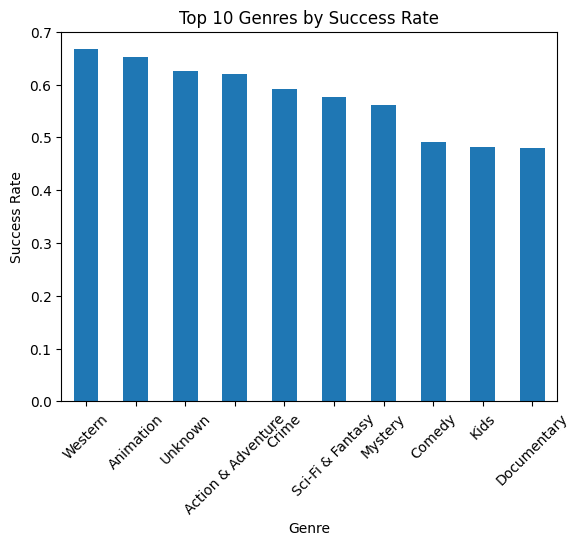

In [36]:
import matplotlib.pyplot as plt

top_genres = df.groupby('main_genre')['success'].mean().sort_values(ascending=False).head(10)

plt.figure()
top_genres.plot(kind='bar')
plt.title("Top 10 Genres by Success Rate")
plt.xlabel("Genre")
plt.ylabel("Success Rate")
plt.xticks(rotation=45)
plt.show()

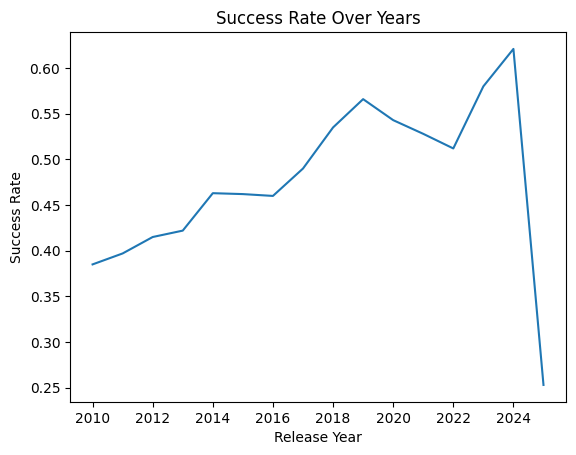

In [37]:
year_success = df.groupby('release_year')['success'].mean()

plt.figure()
year_success.plot()
plt.title("Success Rate Over Years")
plt.xlabel("Release Year")
plt.ylabel("Success Rate")
plt.show()

In [38]:
df['release_year'].unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024, 2025])

In [39]:
df['release_year'].max()

np.int64(2025)

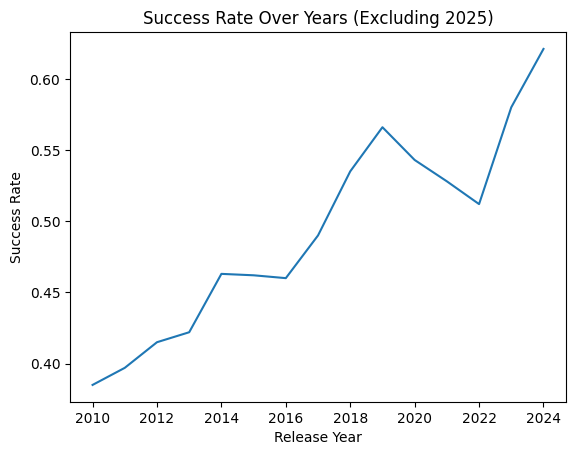

In [40]:
df_no_2025 = df[df['release_year'] < 2025]

year_success_clean = df_no_2025.groupby('release_year')['success'].mean()

plt.figure()
year_success_clean.plot()
plt.title("Success Rate Over Years (Excluding 2025)")
plt.xlabel("Release Year")
plt.ylabel("Success Rate")
plt.show()

In [41]:
df[['popularity', 'vote_average', 'vote_count']].corr()

,popularity,vote_average,vote_count
popularity,1.000000,0.052165,0.145118
vote_average,0.052165,1.000000,0.131719
vote_count,0.145118,0.131719,1.000000


In [42]:
df_model = df_no_2025[['release_year', 
                       'main_genre', 
                       'popularity', 
                       'vote_count', 
                       'success']]

df_model.head()

,release_year,main_genre,popularity,vote_count,success
0,2010,Comedy,1929.898,187,1
1,2010,Talk,1670.580,229,1
2,2010,Reality,1317.092,6,0
3,2010,Reality,1095.776,6,0
4,2010,Talk,712.070,12,0


In [43]:
df_model_encoded = pd.get_dummies(df_model, columns=['main_genre'], drop_first=True)

df_model_encoded.head()

,release_year,popularity,vote_count,success,main_genre_Animation,main_genre_Comedy,main_genre_Crime,main_genre_Documentary,main_genre_Drama,main_genre_Family,main_genre_Kids,main_genre_Mystery,main_genre_News,main_genre_Reality,main_genre_Sci-Fi & Fantasy,main_genre_Soap,main_genre_Talk,main_genre_Unknown,main_genre_War & Politics,main_genre_Western
0,2010,1929.898,187,1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2010,1670.580,229,1,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,2010,1317.092,6,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
3,2010,1095.776,6,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,2010,712.070,12,0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [44]:
from sklearn.model_selection import train_test_split

X = df_model_encoded.drop('success', axis=1)
y = df_model_encoded['success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((12000, 19), (3000, 19))

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
log_model = LogisticRegression(max_iter=3000, solver='liblinear')

# Train
log_model.fit(X_train_scaled, y_train)

# Predict
y_pred_log = log_model.predict(X_test_scaled)

# Accuracy
accuracy_score(y_test, y_pred_log)

0.642

## Model Results

**Observation:**
The model achieved an accuracy of 63%.

**Insight:**
The model is moderately accurate in predicting Netflix show success. Further improvements can be made using better feature engineering or advanced models.

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression again
log_model_scaled = LogisticRegression(max_iter=2000)

log_model_scaled.fit(X_train_scaled, y_train)

# Predict
y_pred_scaled = log_model_scaled.predict(X_test_scaled)

# Accuracy
accuracy_score(y_test, y_pred_scaled)

0.643

In [47]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy_score(y_test, y_pred_rf)

0.687

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
2,vote_count,0.472353
1,popularity,0.359472
0,release_year,0.108545
3,main_genre_Animation,0.011318
7,main_genre_Drama,0.006510
4,main_genre_Comedy,0.005502
12,main_genre_Reality,0.005297
5,main_genre_Crime,0.004249
14,main_genre_Soap,0.004160
6,main_genre_Documentary,0.003825


<Figure size 640x480 with 0 Axes>

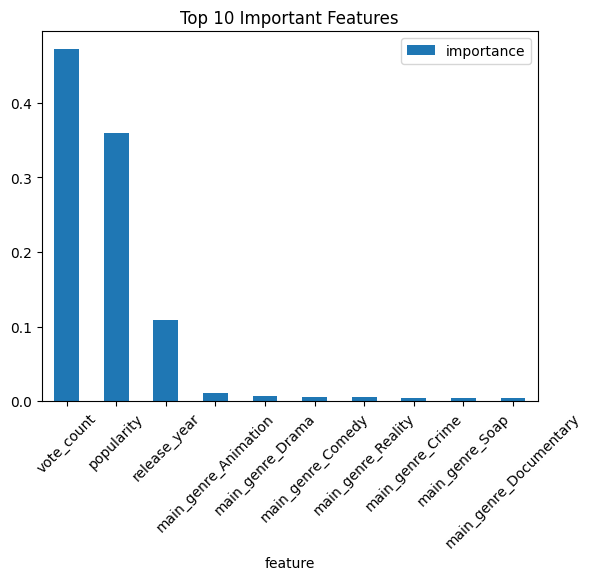

In [49]:
plt.figure()
feature_importance_df.head(10).plot(
    x='feature',
    y='importance',
    kind='bar'
)
plt.title("Top 10 Important Features")
plt.xticks(rotation=45)
plt.show()

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.69      0.66      0.67      1483
           1       0.68      0.72      0.70      1517

    accuracy                           0.69      3000
   macro avg       0.69      0.69      0.69      3000
weighted avg       0.69      0.69      0.69      3000



## Business Insights

- Audience engagement (vote_count) is the strongest predictor of TV show success.
- Success rate has generally increased from 2010 to 2024.
- Certain genres consistently outperform others in success rate.
- Popularity alone showed weak correlation with overall rating performance.
- Random Forest outperformed Logistic Regression, achieving approximately 69% classification accuracy.

## Conclusion

This project demonstrates how engagement metrics and genre information can be used to predict TV show success. The model achieved balanced performance and highlights the importance of audience interaction in content performance analysis.